In [ ]:
import pandas as pd
from pathlib import Path
import statsmodels.api as sm
import pingouin as pg
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import scikit_posthocs as sp
import numpy as np

In [247]:
path = "results.csv"
df = pd.read_csv(path) 

groups = ["HC", "RBD", "PN", "MSA"]

variables = {
    "subharm_num": "Subharmonic cardinality",
    "subharm_per_second" : "Subharmonics per second",

    "subharm_sig_ratio": "Subharmonic-signal ratio",
    "density_num_slope" : "Number-density slope",
    "pct_subharm_num_2nd_half" : "Number-percentage in the second half", 
    "density_dur_slope": "Duration-density slope", 
    "pct_subharm_dur_2nd_half": "Duration-percentage in the second half",

    "first_occur": "First subharmonic occurence",
    "mean_inter_intervals": "Inter-subharmonic interval - mean", 
    "median_inter_intervals": "Inter-subharmonic interval - median",  
    "std_inter_intervals": "Inter-subharmonic interval - standard deviation",  
    "COV_inter_intervals": "Inter-subharmonic interval - CoV",
    
    "avg_dur": "Subharmonic duration - mean",
    "median_dur": "Subharmonic duration - median", 
    "std_dur": "Subharmonic duration - standard deviation", 
    "CV_dur": "Subharmonic duration - CoV", 
    "longest_dur": "Subharmonic duration - the longest",}

# ylabels_count_based = ["Number of subharmonic components [-]", "Number of subharmonic components [-]",]
# ylabels_proportion_based = ["Subharmonic length:total signal length [-]", "NDS [-]", "NPSH [%]", "DDS [-]", "DPSH [%]",]
# ylabels_latency_based = ["First subharmonic occcurence [s]", 
#                         "Mean inter-subharmonic interval [s]", "Median inter-subharmonic interval [s]", 
#                         "Std of inter-subharmonic intervals [s]", "CoV of inter-subharmonic intervals [s]", ]
# ylabels_duration_based = ["Mean subharmonic duration [s]", "Median subharmonic duration [s]", 
#                           "Std of subharmonic durations [s]", "CoV of subharmonic durations [s]", "Longest subharmonic duration [s]",]

ylabels = ["Number of subharmonic components [-]", "Number of subharmonic components [-]",
"Subharmonic length:total signal length [-]", "NDS [-]", "NPSH [%]", "DDS [-]", "DPSH [%]",
"First subharmonic occcurence [s]", 
                        "Mean inter-subharmonic interval [s]", "Median inter-subharmonic interval [s]", 
                        "Std of inter-subharmonic intervals [s]", "CoV of inter-subharmonic intervals [s]",
"Mean subharmonic duration [s]", "Median subharmonic duration [s]", 
                          "Std of subharmonic durations [s]", "CoV of subharmonic durations [s]", "The longest subharmonic duration [s]",]


plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

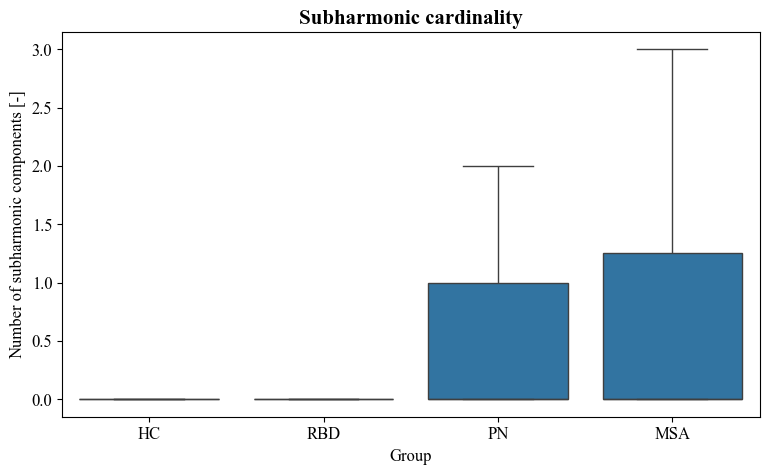

count    672.000000
mean       0.755952
std        2.018534
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max       21.000000
Name: subharm_num, dtype: float64


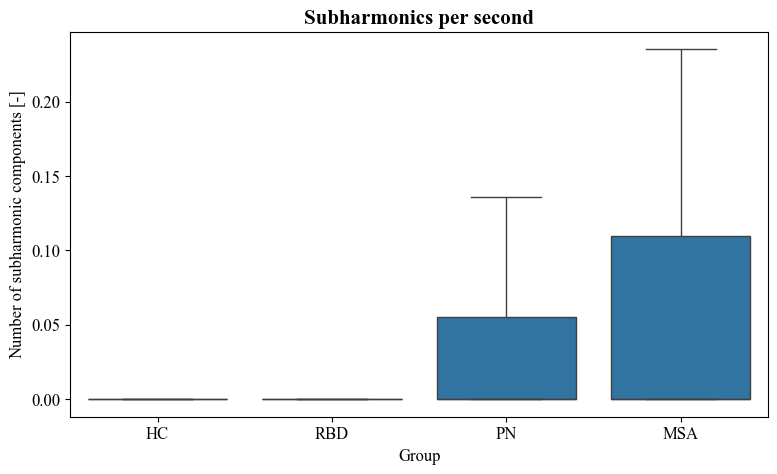

count    672.000000
mean       0.041832
std        0.101299
min        0.000000
25%        0.000000
50%        0.000000
75%        0.024076
max        0.729060
Name: subharm_per_second, dtype: float64


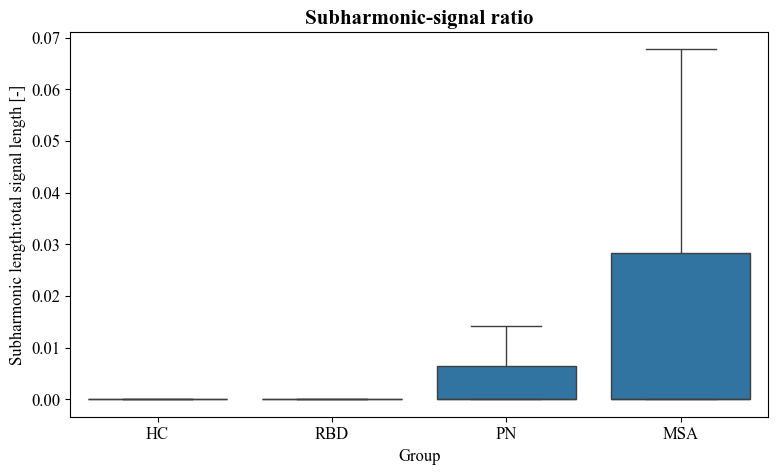

count    672.000000
mean       0.023600
std        0.088913
min        0.000000
25%        0.000000
50%        0.000000
75%        0.002488
max        0.943973
Name: subharm_sig_ratio, dtype: float64


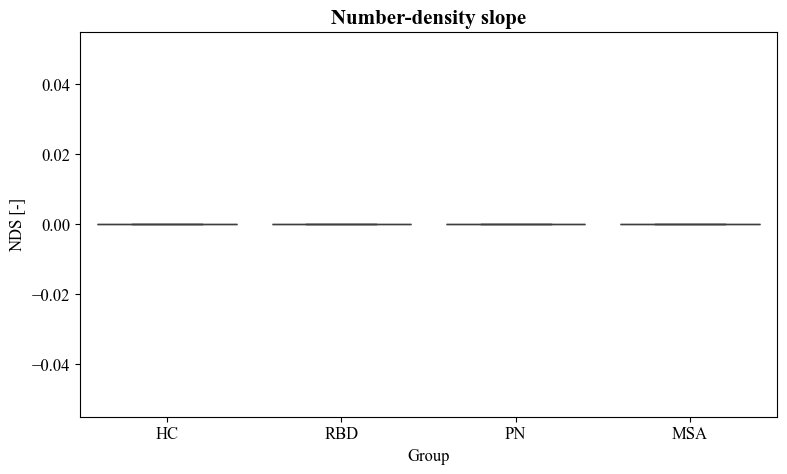

count    672.000000
mean       0.030123
std        0.144035
min       -1.417991
25%        0.000000
50%        0.000000
75%        0.000000
max        0.736296
Name: density_num_slope, dtype: float64


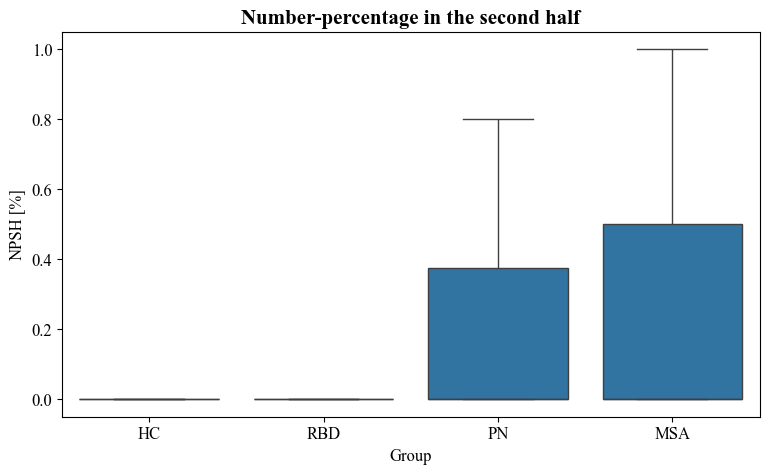

count    672.000000
mean       0.180887
std        0.365822
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: pct_subharm_num_2nd_half, dtype: float64


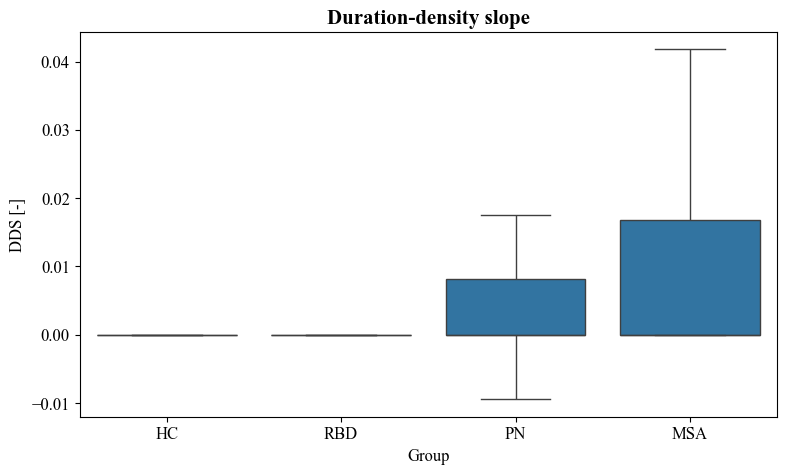

count    672.000000
mean       0.022391
std        0.100647
min       -0.678036
25%        0.000000
50%        0.000000
75%        0.000000
max        0.964811
Name: density_dur_slope, dtype: float64


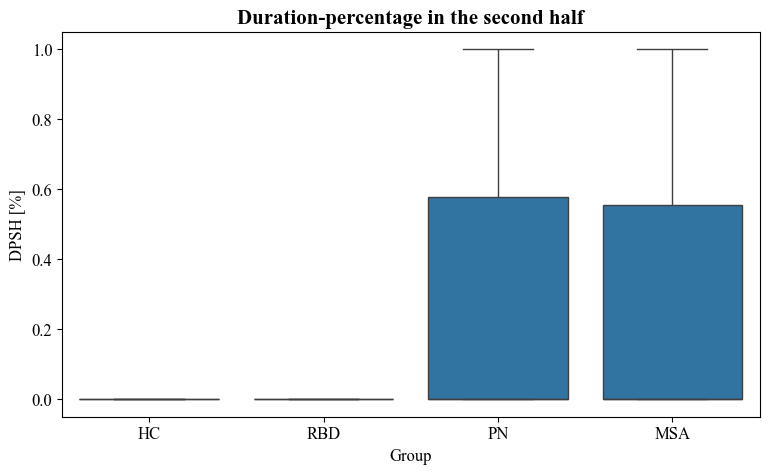

count    672.000000
mean       0.195462
std        0.377654
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: pct_subharm_dur_2nd_half, dtype: float64


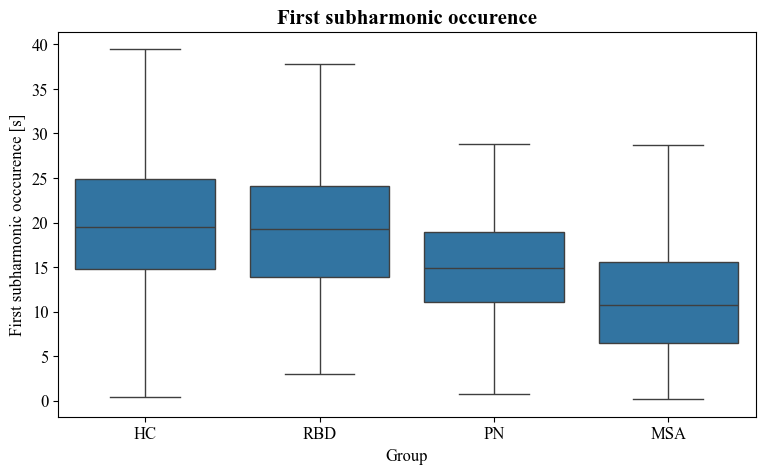

count    672.000000
mean      16.755156
std        8.597849
min        0.162209
25%       10.742318
50%       16.035229
75%       21.356612
max       50.755938
Name: first_occur, dtype: float64


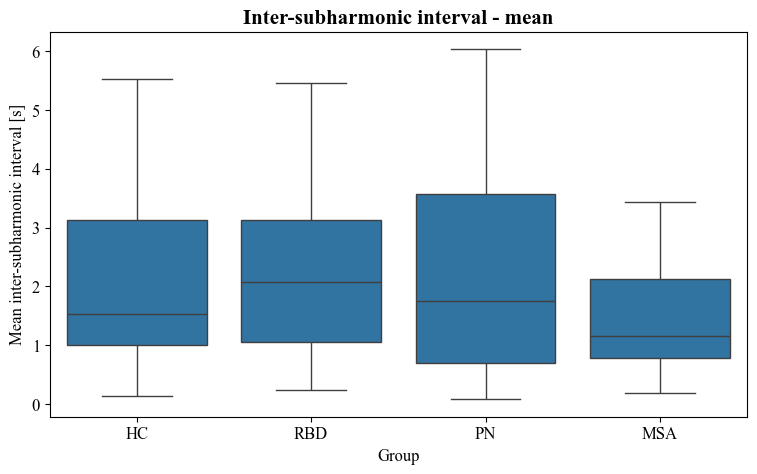

count    94.000000
mean      2.560442
std       3.354541
min       0.081619
25%       0.775072
50%       1.492710
75%       2.830026
max      22.531723
Name: mean_inter_intervals, dtype: float64


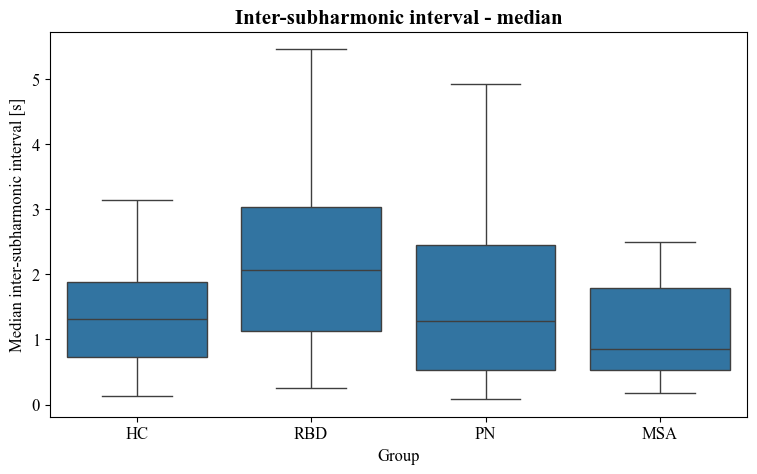

count    94.000000
mean      2.272755
std       3.370692
min       0.081619
25%       0.537059
50%       1.149880
75%       2.256075
max      22.531723
Name: median_inter_intervals, dtype: float64


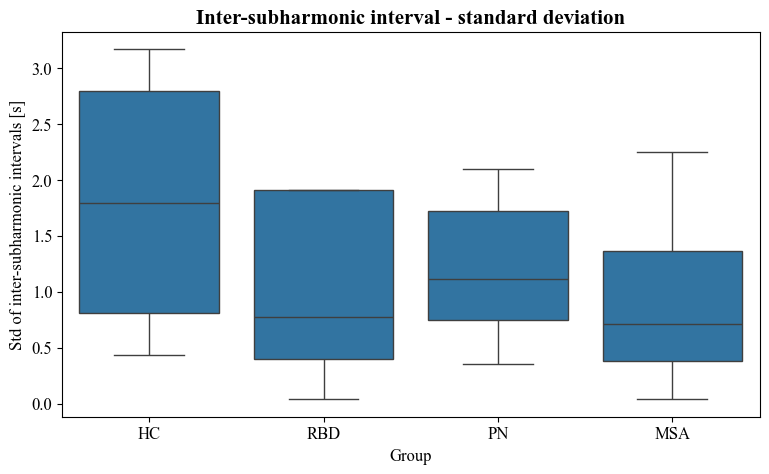

count    64.000000
mean      1.462304
std       1.555259
min       0.039388
25%       0.494143
50%       1.030747
75%       1.790468
max       8.379084
Name: std_inter_intervals, dtype: float64


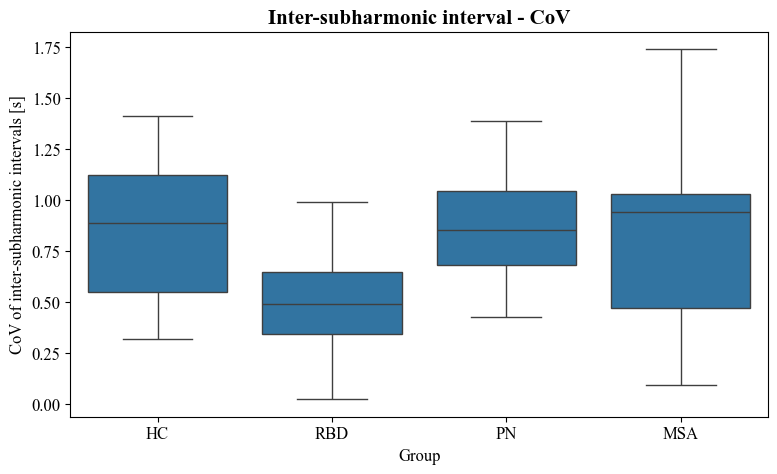

count    64.000000
mean      0.802679
std       0.368846
min       0.023249
25%       0.522395
50%       0.883444
75%       1.034836
max       1.739763
Name: COV_inter_intervals, dtype: float64


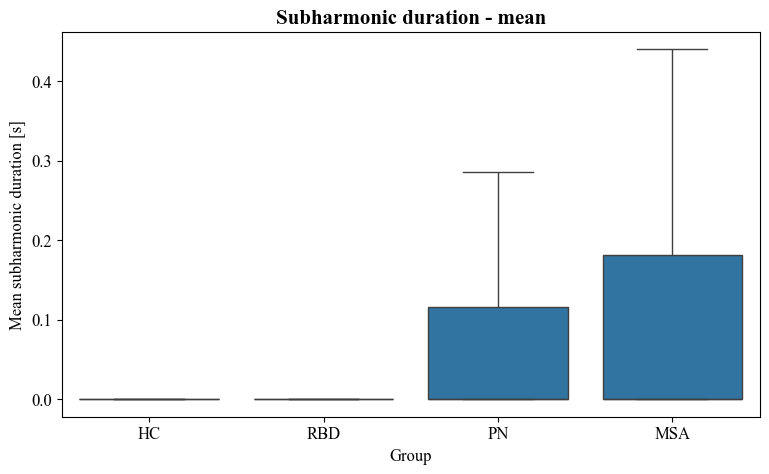

count    672.000000
mean       0.152444
std        0.734724
min        0.000000
25%        0.000000
50%        0.000000
75%        0.053915
max       10.404135
Name: avg_dur, dtype: float64


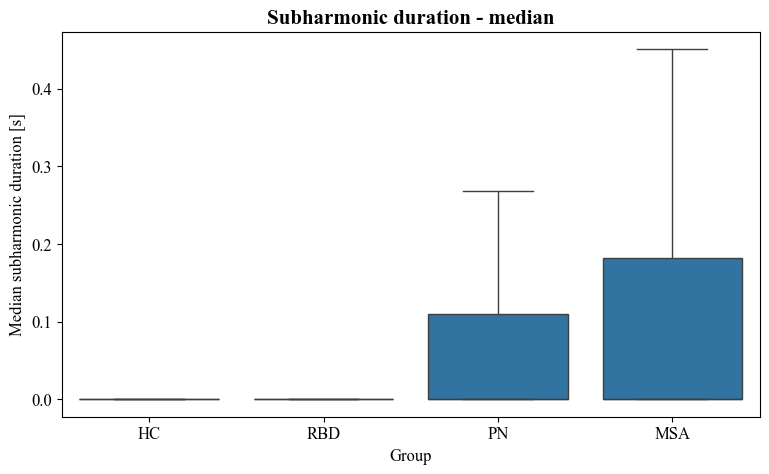

count    672.000000
mean       0.140775
std        0.724739
min        0.000000
25%        0.000000
50%        0.000000
75%        0.053915
max       10.404135
Name: median_dur, dtype: float64


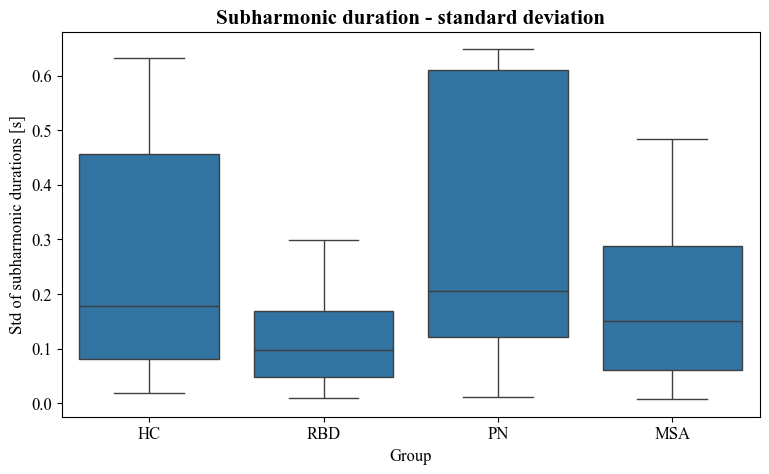

count    94.000000
mean      0.358551
std       0.560097
min       0.007633
25%       0.066252
50%       0.155749
75%       0.307002
max       2.899101
Name: std_dur, dtype: float64


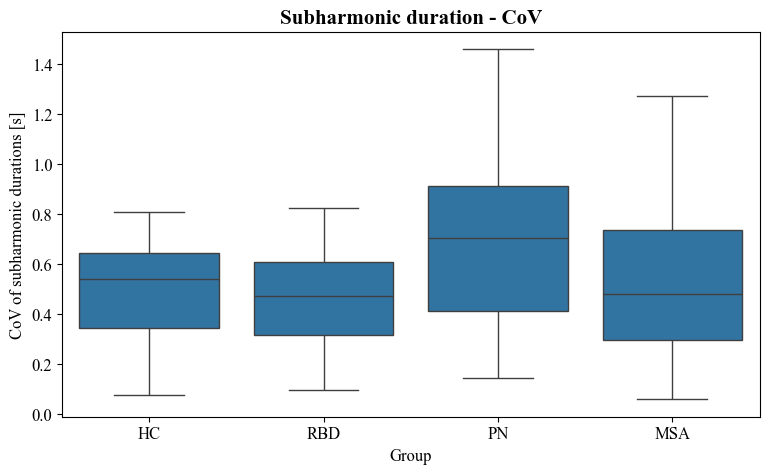

count    94.000000
mean      0.590008
std       0.395220
min       0.059278
25%       0.320585
50%       0.507216
75%       0.782640
max       2.054084
Name: CV_dur, dtype: float64


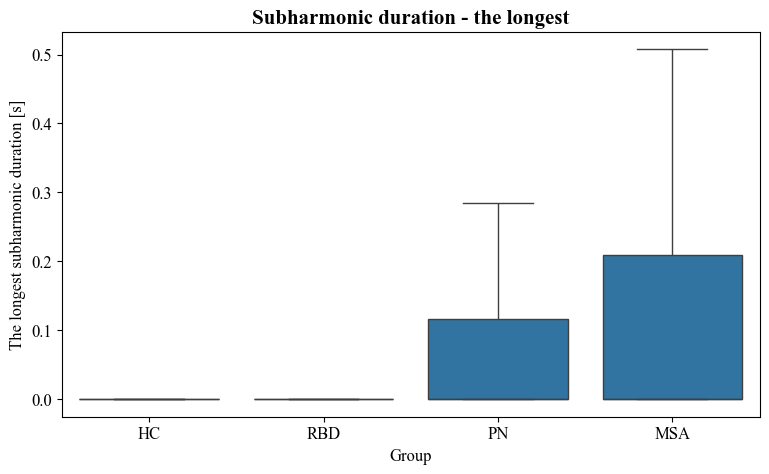

count    672.000000
mean       0.224306
std        0.916112
min        0.000000
25%        0.000000
50%        0.000000
75%        0.053915
max       10.404135
Name: longest_dur, dtype: float64


'\ncount_based = ["subharm_num", "subharm_per_second"]\n\nnrows = int(np.ceil(len(count_based)/2))\nfig, axes = plt.subplots(nrows, 2, figsize=(16, 5*nrows), constrained_layout=True)\naxes = axes.ravel()\n\nfor i, (ax, var, ydata) in enumerate(zip(axes, count_based, ylabels_count_based)):\n    sns.boxplot(data=df, x="group", y=var, order=groups, ax=ax, showfliers=False)\n    # sns.stripplot(data=df, x="group", y=var, order=groups,\n    #               color="black", size=3, alpha=0.5, jitter=0.2, ax=ax)\n\n    ax.set_title(variables[var], fontweight="bold", fontsize=18)\n    ax.set_ylabel(ydata, fontsize=18)\n\n    if i < len(count_based) - 2:\n        ax.set_xlabel("")\n        ax.set_xticklabels([])\n    else:\n        ax.set_xlabel("Group", fontsize=18)\n\nplt.savefig("boxplots/boxplots_count_based.png", dpi=300)\nplt.show()\n\n\n\nproportion_based = ["subharm_sig_ratio", "density_num_slope", "pct_subharm_num_2nd_half", "density_dur_slope", "pct_subharm_dur_2nd_half"]\nnrows = int(n

In [ ]:
    
for i, (var, ydata, title) in enumerate(zip(variables.keys(), ylabels, variables.values())):
    plt.figure(figsize=(9,5))
    sns.boxplot(data=df, x="group", y=var, order=groups, showfliers=False)
    plt.title(title, fontweight="bold")
    plt.ylabel(ydata)
    plt.xlabel("Group")
    plt.savefig(f"boxplots/boxplot_{title}", dpi=300)
    plt.show()

    print(df[var].describe())

---------------------------------------------------------------
                     Subharmonic cardinality
---------------------------------------------------------------

Group medians (for non-zero values):
group
HC     0.0
MSA    0.0
PN     0.0
RBD    0.0
Name: subharm_num, dtype: float64

Group means:
group
HC     0.535714
MSA    1.261905
PN     0.928571
RBD    0.297619
Name: subharm_num, dtype: float64

        Source  ddof1          H     p-unc
Kruskal  group      3  28.438752  0.000003
Effect eta squared: 0.0381
Effect epsilon squared: 0.0424

Mean ranks
group
HC     313.479167
MSA    376.910714
PN     354.077381
RBD    301.532738
Name: rank, dtype: float64

TIME FOR DUNN POST-HOC TEST
           HC       MSA        PN       RBD
HC   1.000000  0.000416  0.035346  0.458618
MSA  0.000416  1.000000  0.313247  0.000018
PN   0.035346  0.313247  1.000000  0.004461
RBD  0.458618  0.000018  0.004461  1.000000
           HC       RBD        PN       MSA
HC   1.000000  0.458618  0.03534

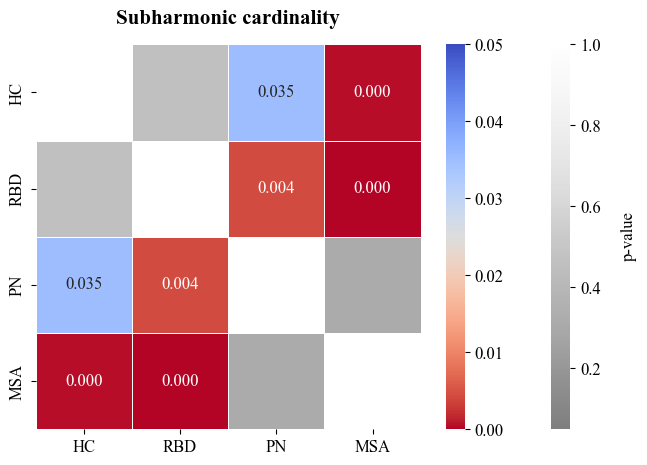


---------------------------------------------------------------
                     Subharmonics per second
---------------------------------------------------------------

Group medians (for non-zero values):
group
HC     0.0
MSA    0.0
PN     0.0
RBD    0.0
Name: subharm_per_second, dtype: float64

Group means:
group
HC     0.026204
MSA    0.078958
PN     0.045172
RBD    0.016996
Name: subharm_per_second, dtype: float64

        Source  ddof1          H         p-unc
Kruskal  group      3  31.154233  7.887991e-07
Effect eta squared: 0.0421
Effect epsilon squared: 0.0464

Mean ranks
group
HC     312.005952
MSA    380.136905
PN     353.107143
RBD    300.750000
Name: rank, dtype: float64

TIME FOR DUNN POST-HOC TEST
           HC       MSA        PN       RBD
HC   1.000000  0.000122  0.032644  0.485565
MSA  0.000122  1.000000  0.187997  0.000005
PN   0.032644  0.187997  1.000000  0.004717
RBD  0.485565  0.000005  0.004717  1.000000
           HC       RBD        PN       MSA
HC   1.00

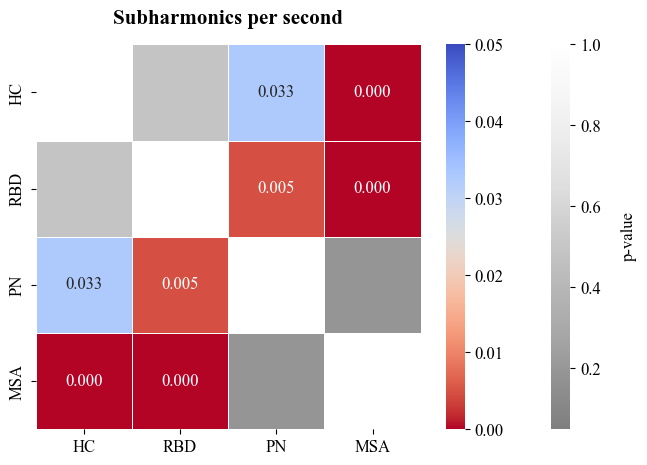


---------------------------------------------------------------
                     Subharmonic-signal ratio
---------------------------------------------------------------

Group medians (for non-zero values):
group
HC     0.0
MSA    0.0
PN     0.0
RBD    0.0
Name: subharm_sig_ratio, dtype: float64

Group means:
group
HC     0.012898
MSA    0.053656
PN     0.024209
RBD    0.003639
Name: subharm_sig_ratio, dtype: float64

        Source  ddof1          H         p-unc
Kruskal  group      3  31.445915  6.847528e-07
Effect eta squared: 0.0426
Effect epsilon squared: 0.0469

Mean ranks
group
HC     312.470238
MSA    379.696429
PN     354.017857
RBD    299.815476
Name: rank, dtype: float64

TIME FOR DUNN POST-HOC TEST
           HC       MSA        PN       RBD
HC   1.000000  0.000156  0.030146  0.433013
MSA  0.000156  1.000000  0.223238  0.000004
PN   0.030146  0.223238  1.000000  0.003138
RBD  0.433013  0.000004  0.003138  1.000000
           HC       RBD        PN       MSA
HC   1.000

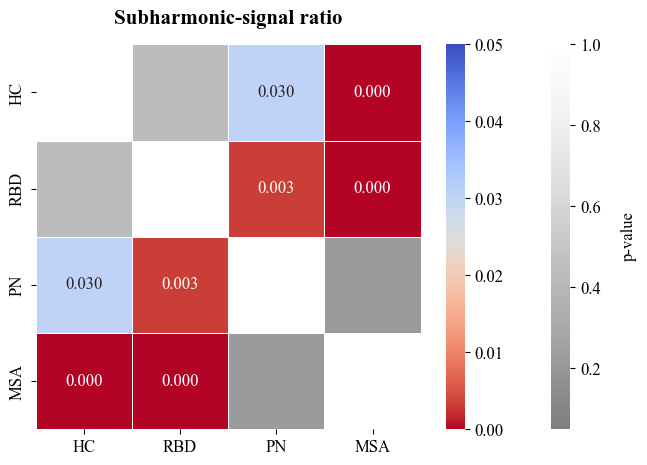


---------------------------------------------------------------
                     Number-density slope
---------------------------------------------------------------

Group medians (for non-zero values):
group
HC     0.0
MSA    0.0
PN     0.0
RBD    0.0
Name: density_num_slope, dtype: float64

Group means:
group
HC     0.021452
MSA    0.042862
PN     0.036690
RBD    0.019488
Name: density_num_slope, dtype: float64

        Source  ddof1         H     p-unc
Kruskal  group      3  4.095312  0.251354
Effect eta squared: 0.0016
Effect epsilon squared: 0.0061

Mean ranks
group
HC     328.517857
MSA    344.190476
PN     350.514881
RBD    322.776786
Name: rank, dtype: float64

---------------------------------------------------------------
                     Number-percentage in the second half
---------------------------------------------------------------

Group medians (for non-zero values):
group
HC     0.0
MSA    0.0
PN     0.0
RBD    0.0
Name: pct_subharm_num_2nd_half, dtype: flo

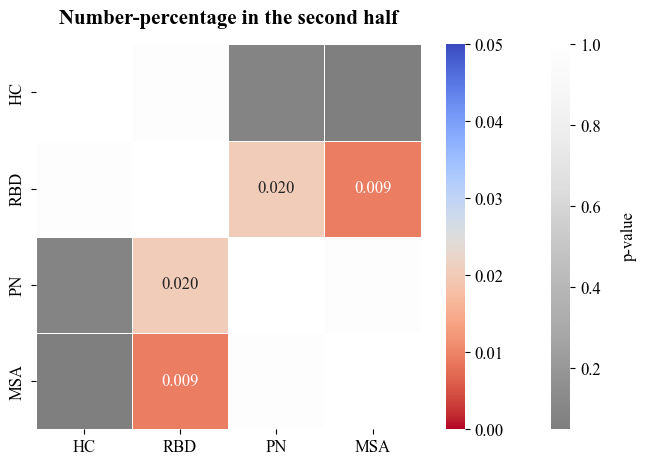


---------------------------------------------------------------
                     Duration-density slope
---------------------------------------------------------------

Group medians (for non-zero values):
group
HC     0.0
MSA    0.0
PN     0.0
RBD    0.0
Name: density_dur_slope, dtype: float64

Group means:
group
HC     0.008927
MSA    0.042519
PN     0.033016
RBD    0.005103
Name: density_dur_slope, dtype: float64

        Source  ddof1          H     p-unc
Kruskal  group      3  16.085411  0.001089
Effect eta squared: 0.0196
Effect epsilon squared: 0.0240

Mean ranks
group
HC     315.886905
MSA    363.952381
PN     354.214286
RBD    311.946429
Name: rank, dtype: float64

TIME FOR DUNN POST-HOC TEST
           HC       MSA        PN       RBD
HC   1.000000  0.014508  0.052699  1.000000
MSA  0.014508  1.000000  1.000000  0.007635
PN   0.052699  1.000000  1.000000  0.035299
RBD  1.000000  0.007635  0.035299  1.000000
           HC       RBD        PN       MSA
HC   1.000000  1.000

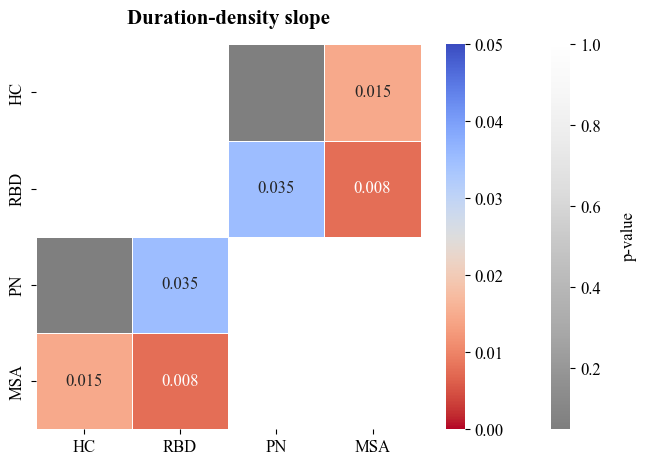


---------------------------------------------------------------
                     Duration-percentage in the second half
---------------------------------------------------------------

Group medians (for non-zero values):
group
HC     0.0
MSA    0.0
PN     0.0
RBD    0.0
Name: pct_subharm_dur_2nd_half, dtype: float64

Group means:
group
HC     0.142842
MSA    0.266520
PN     0.247461
RBD    0.125026
Name: pct_subharm_dur_2nd_half, dtype: float64

        Source  ddof1          H     p-unc
Kruskal  group      3  20.047092  0.000166
Effect eta squared: 0.0255
Effect epsilon squared: 0.0299

Mean ranks
group
HC     316.892857
MSA    366.502976
PN     354.211310
RBD    308.392857
Name: rank, dtype: float64

TIME FOR DUNN POST-HOC TEST
           HC       MSA        PN       RBD
HC   1.000000  0.006547  0.046867  0.851719
MSA  0.006547  1.000000  0.851719  0.001001
PN   0.046867  0.851719  1.000000  0.011979
RBD  0.851719  0.001001  0.011979  1.000000
           HC       RBD        PN 

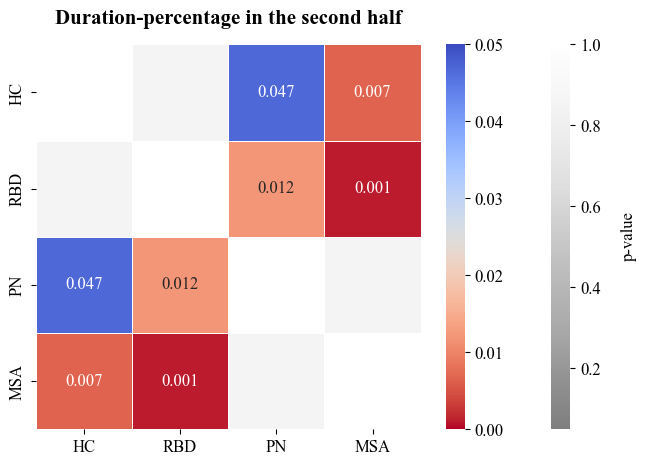


---------------------------------------------------------------
                     First subharmonic occurence
---------------------------------------------------------------

Group medians (for non-zero values):
group
HC     19.486875
MSA    10.764961
PN     14.897256
RBD    19.254427
Name: first_occur, dtype: float64

Group means:
group
HC     20.487485
MSA    11.309911
PN     15.737976
RBD    19.485252
Name: first_occur, dtype: float64

        Source  ddof1          H         p-unc
Kruskal  group      3  130.37979  4.479475e-28
Effect eta squared: 0.1907
Effect epsilon squared: 0.1943

Mean ranks
group
HC     420.059524
MSA    205.928571
PN     314.660714
RBD    405.351190
Name: rank, dtype: float64

TIME FOR DUNN POST-HOC TEST
               HC           MSA        PN           RBD
HC   1.000000e+00  3.017053e-23  0.000002  4.874396e-01
MSA  3.017053e-23  1.000000e+00  0.000001  2.369228e-20
PN   1.948106e-06  1.138865e-06  1.000000  3.712124e-05
RBD  4.874396e-01  2.369228e-20

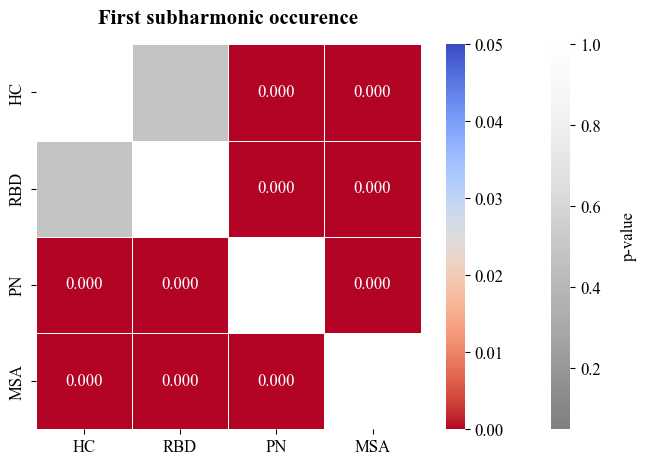


---------------------------------------------------------------
                     Inter-subharmonic interval - mean
---------------------------------------------------------------

Group medians (for non-zero values):
group
HC     1.525500
MSA    1.151440
PN     1.760307
RBD    2.078695
Name: mean_inter_intervals, dtype: float64

Group means:
group
HC     3.437156
MSA    2.196763
PN     2.444776
RBD    2.978396
Name: mean_inter_intervals, dtype: float64

HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1        H     p-unc
Kruskal  group      3  2.31441  0.509766
Effect eta squared: -0.0076
Effect epsilon squared: 0.0249

Mean ranks
group
HC     52.266667
MSA    43.166667
PN     48.640000
RBD    54.333333
Name: rank, dtype: float64

---------------------------------------------------------------
                     Inter-subharmonic interval - median
---------------------------------------------------------------

Group medians (for non-zero values):
group
HC     1.317894
MSA   

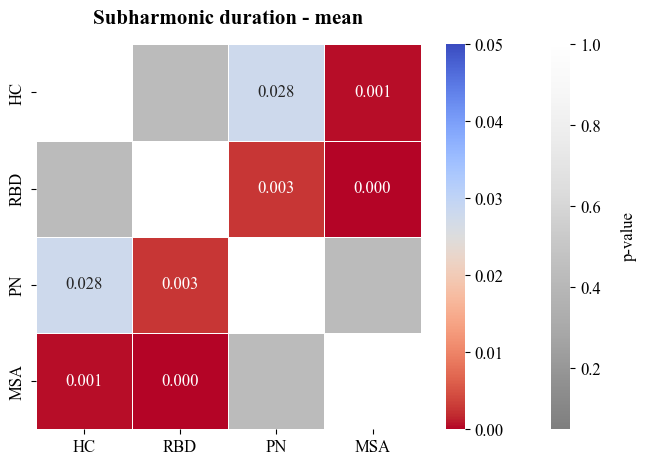


---------------------------------------------------------------
                     Subharmonic duration - median
---------------------------------------------------------------

Group medians (for non-zero values):
group
HC     0.0
MSA    0.0
PN     0.0
RBD    0.0
Name: median_dur, dtype: float64

Group means:
group
HC     0.070864
MSA    0.350037
PN     0.108151
RBD    0.034050
Name: median_dur, dtype: float64

        Source  ddof1          H     p-unc
Kruskal  group      3  28.089777  0.000003
Effect eta squared: 0.0376
Effect epsilon squared: 0.0419

Mean ranks
group
HC     313.952381
MSA    375.690476
PN     355.345238
RBD    301.011905
Name: rank, dtype: float64

TIME FOR DUNN POST-HOC TEST
           HC       MSA        PN       RBD
HC   1.000000  0.000654  0.030992  0.422699
MSA  0.000654  1.000000  0.414962  0.000022
PN   0.030992  0.414962  1.000000  0.003047
RBD  0.422699  0.000022  0.003047  1.000000
           HC       RBD        PN       MSA
HC   1.000000  0.422699  0.

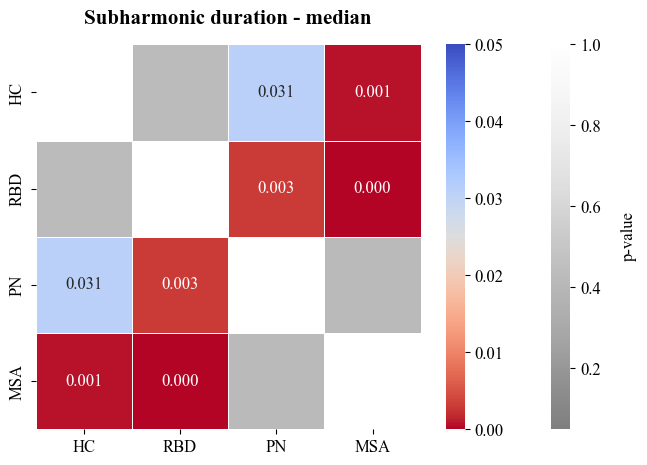


---------------------------------------------------------------
                     Subharmonic duration - standard deviation
---------------------------------------------------------------

Group medians (for non-zero values):
group
HC     0.177644
MSA    0.151208
PN     0.206119
RBD    0.097725
Name: std_dur, dtype: float64

Group means:
group
HC     0.305131
MSA    0.308847
PN     0.589282
RBD    0.118597
Name: std_dur, dtype: float64

HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1         H     p-unc
Kruskal  group      3  5.737902  0.125082
Effect eta squared: 0.0304
Effect epsilon squared: 0.0617

Mean ranks
group
HC     49.466667
MSA    45.047619
PN     56.520000
RBD    34.833333
Name: rank, dtype: float64

---------------------------------------------------------------
                     Subharmonic duration - CoV
---------------------------------------------------------------

Group medians (for non-zero values):
group
HC     0.538654
MSA    0.480184
PN     0.703994


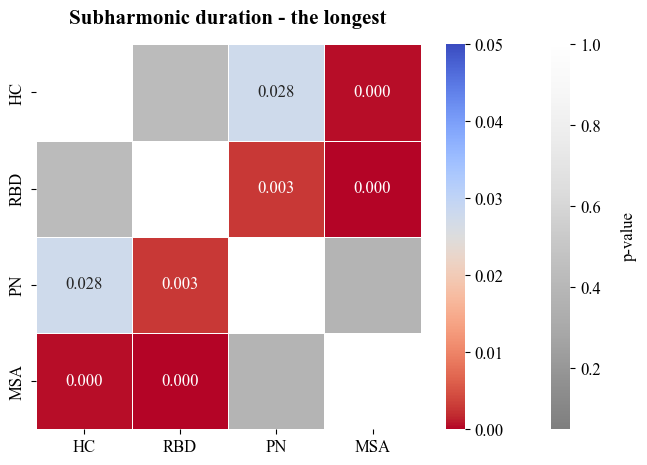

In [259]:
posthoc_counter = 0
posthoc_results = []

for i, (dv, label) in enumerate(variables.items()):
    print("---------------------------------------------------------------")
    print(f"                     {label}")
    print("---------------------------------------------------------------")

    df_clean = df.dropna(subset=[dv]).copy()

    # group_medians = df_clean[df_clean[dv] != 0].groupby("group")[dv].median()
    group_medians = df_clean.groupby("group")[dv].median()
    print("\nGroup medians (for non-zero values):")
    print(group_medians)

    group_means = df_clean.groupby("group")[dv].mean()
    print("\nGroup means:")
    print(group_means)
    print()

    # Shapiro-Wilk normality test
    norm_results = pg.normality(data=df_clean, dv=dv, group="group") # -> norm_results.normal
    if norm_results.normal.all():
        print("NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<")

    # Q-Q plots for all 4 groups
    # fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    # axes = axes.flatten()

    # for ax, grp in zip(axes, groups):
    #     vals = df_clean.loc[df_clean["group"] == grp, dv].dropna()
    #     stats.probplot(vals, dist="norm", plot=ax)
    #     ax.set_title(f"{grp}", fontweight="bold")
    #     ax.set_xlabel("Theoretical quantiles")
    #     ax.set_ylabel("Sample quantiles")
    #     ax.grid(True, alpha=0.3)

    # fig.suptitle(f"Q-Q plots: {label}", fontsize=14, fontweight="bold")
    # plt.tight_layout()
    # plt.savefig(f"qqplots/{label}_qqplot.png", dpi=300, bbox_inches="tight")
    # plt.show()

    # Levene homoscedasticity test
    homo_results = pg.homoscedasticity(data=df_clean, dv=dv, group="group") # -> homo_results.equal_var
    if homo_results.equal_var.iloc[0]:
        print("HOMO <<<<<<<<<<<<<<<<<<<<<<<<<")

    # KRUSKAL-WALLIS GROUP COMPARISON
    kw = pg.kruskal(data=df_clean, dv=dv, between="group")
    print(kw)
    H = kw["H"].values[0]
    k = len(groups)
    n = len(df_clean)
    eta_sq = (H-k+1)/(n-k)
    eps_sq = H/(n-1)
    print(f"Effect eta squared: {eta_sq:.4f}")
    print(f"Effect epsilon squared: {eps_sq:.4f}")

    print("\nMean ranks")
    df_clean["rank"] = df_clean[dv].rank()
    mean_ranks = df_clean.groupby("group")["rank"].mean()
    print(mean_ranks)

    pval = kw["p-unc"].values[0]
    # POST-HOC TEST
    if pval <= 0.05:
        posthoc_counter += 1
        print()
        print("TIME FOR DUNN POST-HOC TEST")
        dunn = sp.posthoc_dunn(df_clean, val_col=dv, group_col="group", p_adjust="holm")
        print(dunn)
        dunn = dunn.loc[groups, groups]
        print(dunn)
        reject = (dunn < 0.05)

        posthoc_results.append({"counter": posthoc_counter, "label": label, "dunn": dunn.copy()})

        n_ticks = 6
        ticks_grey = np.round(np.linspace(0.05, 1.0, n_ticks), 1)   # 1.0 → 0.05
        ticks_color = np.linspace(0.0, 0.05, n_ticks)

        plt.figure(figsize=(8, 5))
        sns.heatmap(dunn, mask=reject, fmt=".3f", cmap='Greys_r', cbar=True, linewidths=0.5, alpha = 0.5, cbar_kws={"label": "p-value", "ticks": ticks_grey}, square=True, vmin=0.05, vmax=1.0)
        sns.heatmap(dunn, mask=~reject, fmt=".3f", cmap='coolwarm_r', cbar=True, linewidths=0.5, annot=True, annot_kws={"size": 12}, square=True, vmin=0.0, vmax=0.05, cbar_kws={"ticks": ticks_color})
        cbar = plt.gca().collections[0].colorbar
        cbar.set_label("p-value", labelpad=15)
        plt.title(f"{label}", fontsize=15, pad=15, fontweight="bold")
        plt.savefig(f"posthoc/{label}_posthoc.png", dpi=300)
        plt.show()
    
    print()


    # Q–Q plot (on residuals)

    # --- Residuals vs Fitted plot ---

In [ ]:
# plt.tight_layout()
# plt.savefig("qqplots.png", dpi=300)
# plt.show()

# fig_rvf.savefig("residuals_vs_fitted.png", dpi=300)

"""
count_based = ["subharm_num", "subharm_per_second"]

nrows = int(np.ceil(len(count_based)/2))
fig, axes = plt.subplots(nrows, 2, figsize=(16, 5*nrows), constrained_layout=True)
axes = axes.ravel()

for i, (ax, var, ydata) in enumerate(zip(axes, count_based, ylabels_count_based)):
    sns.boxplot(data=df, x="group", y=var, order=groups, ax=ax, showfliers=False)
    # sns.stripplot(data=df, x="group", y=var, order=groups,
    #               color="black", size=3, alpha=0.5, jitter=0.2, ax=ax)

    ax.set_title(variables[var], fontweight="bold", fontsize=18)
    ax.set_ylabel(ydata, fontsize=18)

    if i < len(count_based) - 2:
        ax.set_xlabel("")
        ax.set_xticklabels([])
    else:
        ax.set_xlabel("Group", fontsize=18)

plt.savefig("boxplots/boxplots_count_based.png", dpi=300)
plt.show()



proportion_based = ["subharm_sig_ratio", "density_num_slope", "pct_subharm_num_2nd_half", "density_dur_slope", "pct_subharm_dur_2nd_half"]
nrows = int(np.ceil(len(proportion_based)/2))
fig, axes = plt.subplots(nrows, 2, figsize=(16, 5*nrows), constrained_layout=True)
axes = axes.ravel()

for i, (ax, var, ydata) in enumerate(zip(axes, proportion_based, ylabels_proportion_based)):
    sns.boxplot(data=df, x="group", y=var, order=groups, ax=ax, showfliers=False)

    ax.set_title(variables[var], fontweight="bold")
    ax.set_ylabel(ydata)

    if i < len(proportion_based) - 2:
        ax.set_xlabel("")
        ax.set_xticklabels([])
    else:
        ax.set_xlabel("Group")

plt.savefig("boxplots/boxplots_proportion_based.png", dpi=300)
plt.show()




latency_based = ["first_occur", "mean_inter_intervals", "median_inter_intervals", "std_inter_intervals", "COV_inter_intervals",]
nrows = int(np.ceil(len(latency_based)/2))
fig, axes = plt.subplots(nrows, 2, figsize=(16, 5*nrows), constrained_layout=True)
axes = axes.ravel()

for i, (ax, var, ydata) in enumerate(zip(axes, latency_based, ylabels_latency_based)):
    sns.boxplot(data=df, x="group", y=var, order=groups, ax=ax, showfliers=False)

    ax.set_title(variables[var], fontweight="bold")
    ax.set_ylabel(ydata)

    if i < len(latency_based) - 2:
        ax.set_xlabel("")
        ax.set_xticklabels([])
    else:
        ax.set_xlabel("Group")

plt.savefig("boxplots/boxplots_latency_based.png", dpi=300)
plt.show()



duration_based = ["avg_dur", "median_dur",  "std_dur",  "CV_dur",  "longest_dur",]
nrows = int(np.ceil(len(duration_based)/2))
fig, axes = plt.subplots(nrows, 2, figsize=(16, 5*nrows), constrained_layout=True)
axes = axes.ravel()

for i, (ax, var, ydata) in enumerate(zip(axes, duration_based, ylabels_duration_based)):
    sns.boxplot(data=df, x="group", y=var, order=groups, ax=ax, showfliers=False)

    ax.set_title(variables[var], fontweight="bold")
    ax.set_ylabel(ydata)

    if i < len(duration_based) - 2:
        ax.set_xlabel("")
        ax.set_xticklabels([])
    else:
        ax.set_xlabel("Group")

plt.savefig("boxplots/boxplots_duration_based.png", dpi=300)
plt.show()


"""